In [1]:
%load_ext autoreload
%autoreload 2

## 1. Imports

In [21]:
import os
import sys

sys.path.append("..")

import matplotlib.cm as cm
import numpy as np
import torch
import wandb
from matplotlib import pyplot as plt
from tqdm import tqdm

from src.distributions import StandardNormalSampler, SwissRollSampler
from src.light_gcot import LightGCOT

In [22]:
device = torch.device(f"cuda:{torch.cuda.current_device()}" if torch.cuda.is_available() else "cpu")
device

device(type='cuda', index=0)

In [23]:
torch.set_default_device(device)
# torch.set_default_tensor_type(torch.DoubleTensor)

## 2. Config

In [24]:
X_DIM = 2
Y_DIM = 2
assert X_DIM > 1
# assert Y_DIM > 1

OUTPUT_SEED = 42

N_POTENTIALS = 500
M_POTENTIALS = 100
INIT_BY_SAMPLES = False
A_DIAGONAL_INIT = 0.1
IS_B_DIAGONAL = True

BATCH_SIZE = 128
SAMPLING_BATCH_SIZE = 128

EPSILON = 0.002

D_LR = 3e-4  # 1e-3 for eps 0.1, 0.01 and 3e-4 for eps 0.002
D_GRADIENT_MAX_NORM = float("inf")

PLOT_EVERY = 500
MAX_STEPS = 20000
CONTINUE = -1

In [25]:
torch.manual_seed(OUTPUT_SEED)

In [26]:
EXP_COST = "MLP"
EXP_COST_INCLUDED = True
EXP_META_INFO = "c(x,y)=||x+y||^2"
EXP_NAME = (
    f"LightGCOT_Swiss_Roll_EPSILON_{EPSILON}_MAX_STEPS_{MAX_STEPS}_N_{N_POTENTIALS}_M_{M_POTENTIALS}_with_{EXP_COST}_cost_included_{EXP_COST_INCLUDED}"
    + EXP_META_INFO
)
OUTPUT_PATH = "../checkpoints/{}".format(EXP_NAME)

config = dict(
    X_DIM=X_DIM,
    Y_DIM=Y_DIM,
    D_LR=D_LR,
    BATCH_SIZE=BATCH_SIZE,
    EPSILON=EPSILON,
    D_GRADIENT_MAX_NORM=D_GRADIENT_MAX_NORM,
    N_POTENTIALS=N_POTENTIALS,
    M_POTENTIALS=M_POTENTIALS,
    INIT_BY_SAMPLES=INIT_BY_SAMPLES,
    A_DIAGONAL_INIT=A_DIAGONAL_INIT,
    IS_B_DIAGONAL=IS_B_DIAGONAL,
)

if not os.path.exists(OUTPUT_PATH):
    os.makedirs(OUTPUT_PATH)

## 3. Create samplers

In [27]:
X_sampler = StandardNormalSampler(dim=X_DIM, device=device)
Y_sampler = SwissRollSampler(dim=Y_DIM, device=device)

## 4. Model initialization

In [35]:
D = LightGCOT(
    x_dim=X_DIM,
    y_dim=Y_DIM,
    n_potentials=N_POTENTIALS,
    m_potentials=M_POTENTIALS,
    epsilon=EPSILON,
    sampling_batch_size=SAMPLING_BATCH_SIZE,
    A_diagonal_init=A_DIAGONAL_INIT,
    is_B_diagonal=IS_B_DIAGONAL,
    cost_function=EXP_COST,
)

if INIT_BY_SAMPLES:
    D.init_a_by_samples(Y_sampler.sample(N_POTENTIALS))

D_opt = torch.optim.Adam(D.parameters(), lr=D_LR)

if CONTINUE > -1:
    D_opt.load_state_dict(torch.load(os.path.join(OUTPUT_PATH, f"D_opt_{OUTPUT_SEED}_{CONTINUE}.pt")))

## 5. Model training

In [29]:
from src.discrete_ot import OTPlanSampler

In [30]:
otp_sampler = OTPlanSampler("sinkhorn")

In [31]:
NUM_STARTING_POINTS = 2
NUM_ENDING_POINTS = 256

In [32]:
colors_chosen = cm.rainbow(np.linspace(0.1, 0.9, NUM_STARTING_POINTS))

In [44]:
def plot(model_: LightGCOT, num_sample: int = 1024, log: bool = False) -> str:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5), dpi=200)

    for ax in axes:
        ax.grid(zorder=-20)

    x_samples = X_sampler.sample(num_sample)
    y_samples = Y_sampler.sample(num_sample)
    tr_samples = torch.tensor([[-1.5, -1.5], [0.0, 0.0], [1.0, -2.0], [-1.5, 1.25], [1.5, 2.0]])[:NUM_STARTING_POINTS]

    tr_samples = tr_samples[None].repeat(NUM_ENDING_POINTS, 1, 1).reshape(NUM_STARTING_POINTS * NUM_ENDING_POINTS, 2)

    # First plot
    axes[0].scatter(
        x_samples[:, 0].cpu().numpy(),
        x_samples[:, 1].cpu().numpy(),
        alpha=0.3,
        c="g",
        s=32,
        edgecolors="black",
        label=r"Input distirubtion $p_0$",
    )
    axes[0].scatter(
        y_samples[:, 0].cpu().numpy(),
        y_samples[:, 1].cpu().numpy(),
        c="orange",
        s=32,
        edgecolors="black",
        label=r"Target distribution $p_1$",
    )

    # Third plot
    b_m = D.compute_b_m(tr_samples)
    B_m = D.compute_B_m(tr_samples)
    log_v_m = D.compute_log_v_m(tr_samples)
    y_cost_sample = D.compute_cost(b_m, B_m, log_v_m, sample=True).cpu().numpy()
    for i in range(NUM_STARTING_POINTS):
        axes[2].scatter(
            y_cost_sample[torch.arange(i, NUM_STARTING_POINTS * NUM_ENDING_POINTS, NUM_STARTING_POINTS).cpu().numpy(), 0],
            y_cost_sample[torch.arange(i, NUM_STARTING_POINTS * NUM_ENDING_POINTS, NUM_STARTING_POINTS).cpu().numpy(), 1],
            c=colors_chosen[i],
            s=32,
            edgecolors="black",
            label=r"Cost distribution",
        )

    # Second plot
    for ax, model in zip([axes[1]], [model_]):
        y_pred = model(x_samples).cpu().numpy()

        ax.scatter(
            y_pred[:, 0], y_pred[:, 1], c="yellow", s=32, edgecolors="black", label="Fitted distribution", zorder=1
        )

        tr_samples_pred = model(tr_samples).cpu().numpy()
        for i in range(NUM_ENDING_POINTS):
            for j, (point, point_pred) in enumerate(
                zip(
                    tr_samples[i * NUM_STARTING_POINTS : (i + 1) * NUM_STARTING_POINTS].cpu().numpy(),
                    tr_samples_pred[i * NUM_STARTING_POINTS : (i + 1) * NUM_STARTING_POINTS],
                )
            ):
                ax.scatter(
                    point[0],
                    point[1],
                    color=colors_chosen[j],
                    s=48,
                    # label=r"Trajectory start ($x \sim p_0$)",
                    zorder=3,
                    edgecolors="black",
                )
                ax.scatter(
                    point_pred[0],
                    point_pred[1],
                    color=colors_chosen[j],
                    s=32,
                    # label=r"Trajectory end ($x \sim p_1$)",
                    zorder=3,
                    edgecolors="black",
                )
                # ax.arrow(
                #     point[0],
                #     point[1],
                #     point_pred[0] - point[0],
                #     point_pred[1] - point[1],
                # )

    for i, ax in enumerate(axes):
        ax.set_xlim([-3.5, 3.5])
        ax.set_ylim([-3.5, 3.5])
        ax.legend(loc="lower left")

    fig.tight_layout(pad=0.1)

    if log:
        wandb.log({"Image": wandb.Image(fig)})
        plt.close(fig)
    else:
        plt.show()

In [39]:
wandb.init(name=EXP_NAME, config=config)

for step in tqdm(range(CONTINUE + 1, MAX_STEPS)):
    # training loop
    D_opt.zero_grad()

    if EXP_COST_INCLUDED:
        _X, _Y = X_sampler.sample(BATCH_SIZE), Y_sampler.sample(BATCH_SIZE)
        X, Y = otp_sampler.sample_plan(_X, _Y)
    else:
        X, Y = X_sampler.sample(BATCH_SIZE), Y_sampler.sample(BATCH_SIZE)

    b_m = D.compute_b_m(X)  # [bs x M x y_dim]
    B_m = D.compute_B_m(X)  # [bs x M x y_dim]
    log_v_m = D.compute_log_v_m(X)  # [bs x M]

    f_c = D.compute_dual_potential(b_m, B_m, log_v_m)
    f = D.compute_primal_potential(Y)

    if EXP_COST_INCLUDED:
        c = D.compute_cost(b_m, B_m, log_v_m, False, Y)
        D_loss = (c - f_c - f).mean()
        D_loss.backward()
    else:
        D_loss = -(f_c + f).mean()
        D_loss.backward()
    D_gradient_norm = torch.nn.utils.clip_grad_norm_(D.parameters(), max_norm=D_GRADIENT_MAX_NORM)
    D_opt.step()

    wandb.log({f"D gradient norm": D_gradient_norm.item()}, step=step)
    wandb.log({f"D_loss": D_loss.item()}, step=step)
    wandb.log({f"lam_min(A_n)": torch.min(D.A_diagonal_matrix)}, step=step)
    wandb.log({f"lam_max(A_n)": torch.max(D.A_diagonal_matrix)}, step=step)
    wandb.log({f"lam_min(B_m)": torch.min(D.B_m_matrix)}, step=step)
    wandb.log({f"lam_max(B_m)": torch.max(D.B_m_matrix)}, step=step)

    if step % PLOT_EVERY == 0:
        plot(D, log=True)

torch.save(D.state_dict(), os.path.join(OUTPUT_PATH, f"D.pt"))
torch.save(D_opt.state_dict(), os.path.join(OUTPUT_PATH, f"D_opt.pt"))

wandb.finish()

D gradient norm,▁
D_loss,▁
lam_max(A_n),▁
lam_max(B_m),▁
lam_min(A_n),▁
lam_min(B_m),▁
D gradient norm,0.0617
D_loss,0.03558
lam_max(A_n),0.1003
lam_max(B_m),1.0
lam_min(A_n),0.0997


  0%|                                                                                                                                                                                 | 0/20000 [00:00<?, ?it/s]/tmp/ipykernel_1458929/1831241524.py:38: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  axes[2].scatter(
  0%|                                                                                                                                                                      | 1/20000 [00:07<42:03:49,  7.57s/it]/trinity/home/m.persiyanov/miniconda3/envs/light-gcot/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:531: UserWarning: Sinkhorn did not converge. You might want to increase the number of i

D gradient norm,█▇▅▅▄▃▅▄▃▂▄▂▃▂▂▂▂▂▁▂▂▂▁▂▁▂▂▂▁▁▁▁▂▁▂▁▁▂▂▂
D_loss,█▇▅▅▃▃▄▃▃▃▃▃▃▃▂▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁
lam_max(A_n),▁▁▁▁▂▂▂▂▂▂▂▂▂▂▃▃▃▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▇▇█
lam_max(B_m),▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇██
lam_min(A_n),█▃▄▄▄▄▄▄▆█▆█▇▇▇▆█▇▇▇▇▇▇▆█▇▇▇█▇▇▇▆▅▅▅▄▃▁▁
lam_min(B_m),▁▁▁▂▂▃▃▄▄▄▅▅▅▆▇▇▇▇▇▇▇▇▇▇▇▇▇█████████████
D gradient norm,0.01408
D_loss,-0.00496
lam_max(A_n),4.06886
lam_max(B_m),4.60445
lam_min(A_n),-0.00652


## Plotting

/tmp/ipykernel_1458929/377760778.py:38: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  axes[2].scatter(


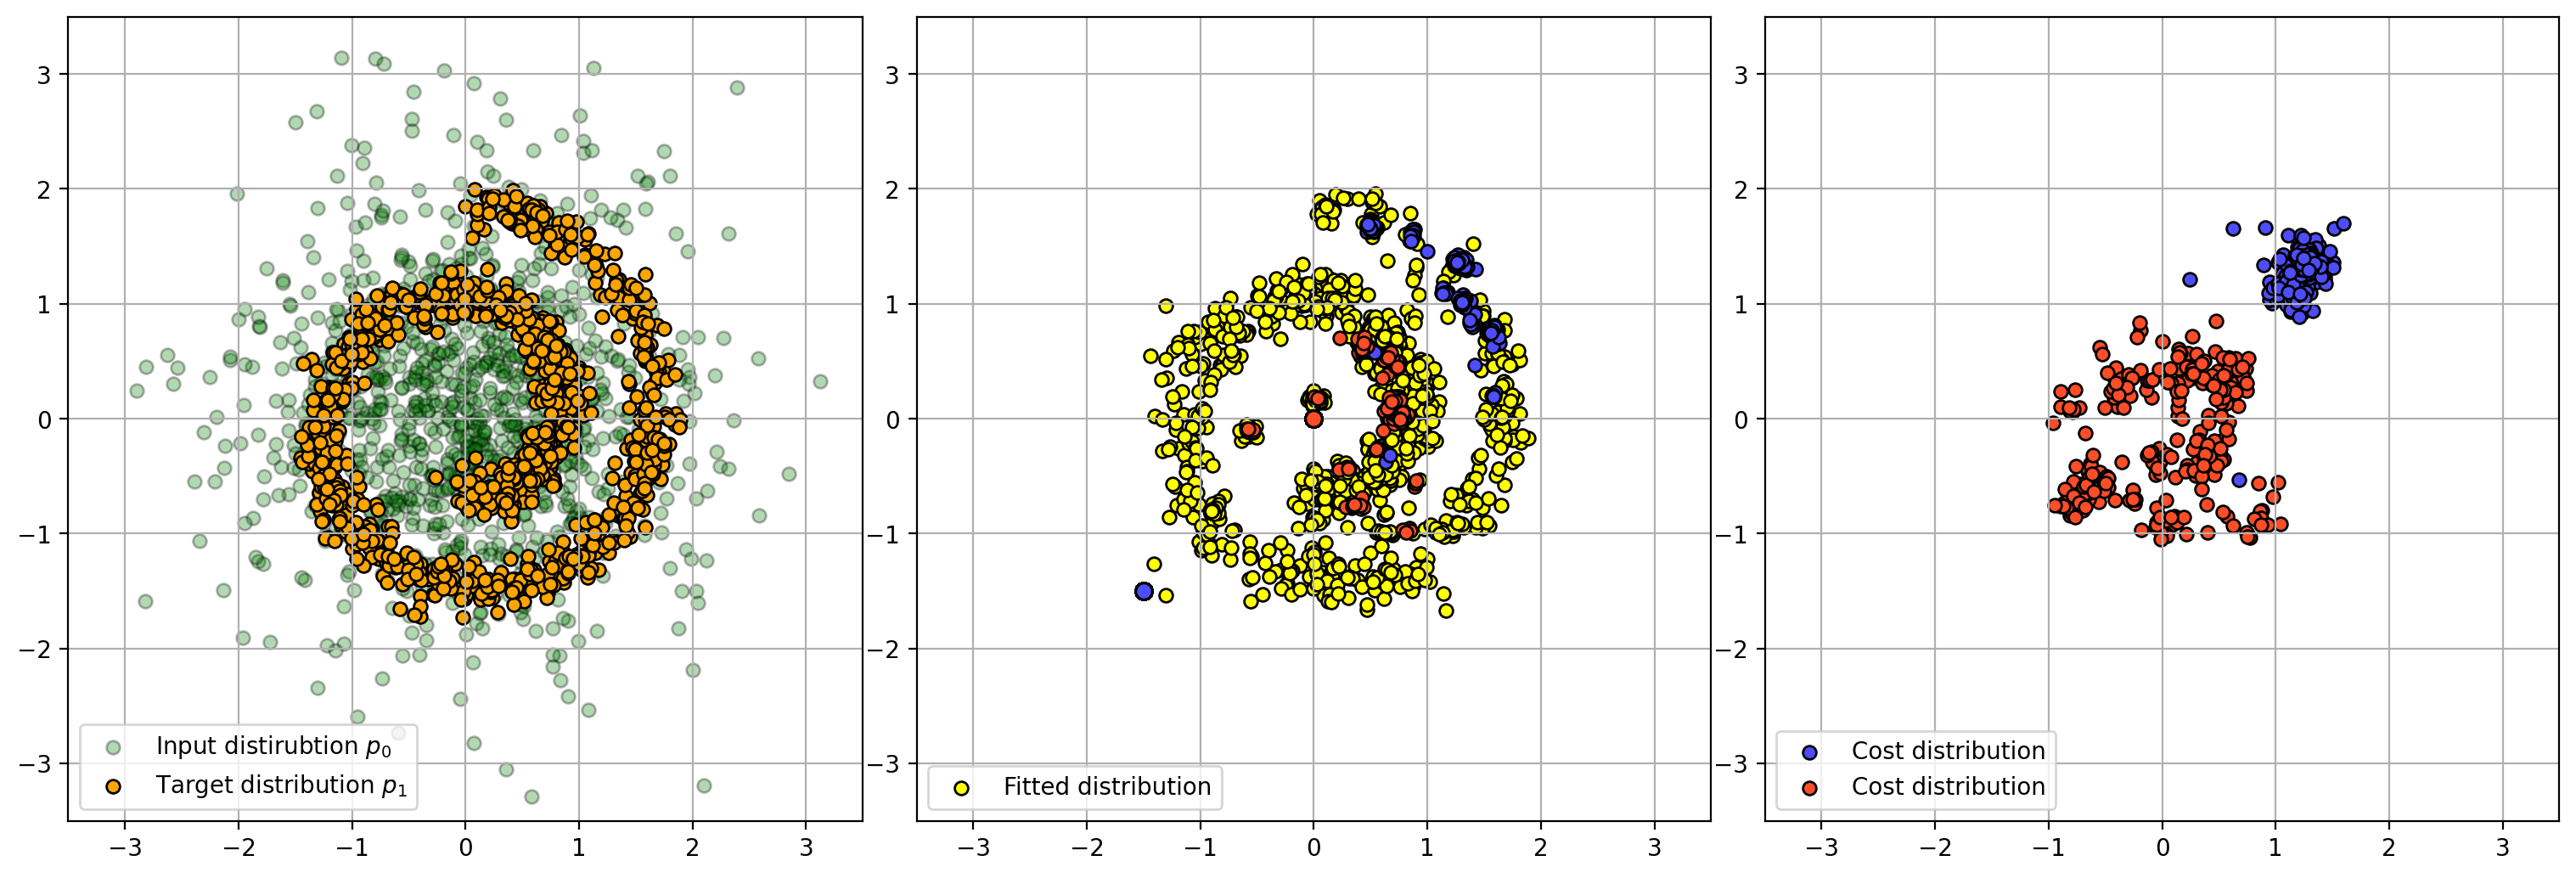

In [45]:
plot(D)

In [46]:
torch.save(D.state_dict(), os.path.join(OUTPUT_PATH, f"D.pt"))
torch.save(D_opt.state_dict(), os.path.join(OUTPUT_PATH, f"D_opt.pt"))

In [47]:
OUTPUT_PATH

'../checkpoints/LightGCOT_Swiss_Roll_EPSILON_0.002_MAX_STEPS_20000_N_500_M_100_with_MLP_cost_included_True-M'